In [36]:
import ChessLens

from matplotlib import pyplot as plt
import numpy as np
import cv2

import torch

from Dataset.DataSetLoaders.ChessDataset import ChessDataset

In [2]:
dataset = ChessDataset(
    config={
        "img_size": (640,640)
    }
)
dataloader = ChessDataset.getLoader(dataset, batch_size=4, num_worders=0)

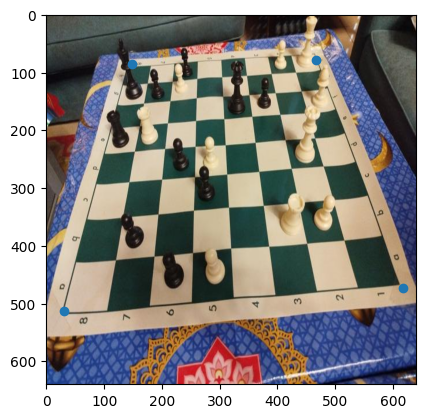

In [22]:
# for img, label in dataset:
    # _, H, W = img.shape
    # print(label)
    # plt.imshow(img.permute(1,2,0));
    # plt.scatter(label["corners"][:,0], label["corners"][:,1])

    # print(H, W)
    # break

img, _ = dataset[50]

# img = ChessLens.ChessLensImage("./Dataset/img_3.jpeg")
img = ChessLens.ChessLensImage(img, "yolo")
img.detect_board()
_, H, W = img.img.shape
label = {
    "corners": img.board_detection
}

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);

In [23]:
s = 0
cx = W/2
cy = H/2

In [24]:
# fx = 2739.79 * 640 / 2304
# fy = 2739.79 * 640/1728
fx = 2739.79 * W/4032
fy = 2739.79 * H/3024

K = np.array([
    [fx, s, cx],
    [0, fy, cy],
    [0,  0,  1]
]) # K: intrinsics of 3d -> 2d

In [25]:
cam_point = np.array([0,0,.5])
Z = cam_point[2]

def extrinsics_from_planar_points(image_pts, K, L=1.0):
    """
    image_pts: (4,2) image coordinates in pixels, in known order (clockwise or ccw)
    K: 3x3 camera intrinsics
    L: side length of the square in world coordinates (any unit)
    Returns:
        R: 3x3 rotation matrix (world→camera)
        t: 3x1 translation vector (world→camera)
        H: 3x3 homography (plane→image)
    """
    # Define square points on the world plane Z=0
    world_pts = np.array([
        [0, 0],
        [L, 0],
        [L, L],
        [0, L]
    ], dtype=np.float64)

    # Find homography (plane -> image)
    H, _ = cv2.findHomography(world_pts, image_pts)

    # Decompose using intrinsics
    K_inv = np.linalg.inv(K)
    h1, h2, h3 = H[:,0], H[:,1], H[:,2]

    # Normalize rotation columns
    lam = 1.0 / np.linalg.norm(K_inv @ h1)
    r1 = lam * (K_inv @ h1)
    r2 = lam * (K_inv @ h2)
    r3 = np.cross(r1, r2)

    R = np.column_stack((r1, r2, r3))
    # Enforce orthonormality via SVD
    U, _, Vt = np.linalg.svd(R)
    R = U @ Vt

    # Ensure a right-handed coordinate system
    if np.linalg.det(R) < 0:
        R[:, 2] *= -1

    t = lam * (K_inv @ h3)
    return R, t.reshape(3,1), H


# r_val = 1/np.sqrt(2)
# R_ = np.array([
#     [1, 0, 0],
#     [0, -r_val, -r_val],
#     [0, r_val, -r_val],
# ])

R_, t, H = extrinsics_from_planar_points(img.board_detection.numpy(), K, 1)
pitch = np.degrees(np.arctan2(R_[2,1], R_[1,1]))
print(pitch)

t = (-R_) @ cam_point.reshape((3,1))
# t = np.array([
#     [0],
#     [-Z * r_val],
#     [Z * r_val]
# ])

R = np.concat([R_, t], axis=1)
R = np.concat([R, np.array([[0,0,0,1]])], axis=0) # R: extrinsics of World -> Camera

-38.66698745445827


In [26]:
def from_3d_to_2d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ R.T
    res_points = (res_points / res_points[:,[3]])[:, :3]
    res_points = res_points @ K.T
    res_points = (res_points/res_points[:, [2]])[:, :2]
    return res_points

def from_2d_to_3d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(K).T

    points_ = np.concat([res_points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(R).T
    res_points = (res_points/res_points[:, [3]])[:, :3]

    return res_points

def trace_ray(directions: np.ndarray, cam_point: np.ndarray, Z_0: np.ndarray):
    N = directions.shape[0]
    if directions.shape[1] != 3 or len(directions.shape) != 2 \
        or cam_point.shape[0] != 3 or len(cam_point.shape) != 1 \
        or Z_0.shape[0] != N or len(Z_0.shape) != 1:
        raise Exception("Invalid input")
    
    t = ((Z_0-cam_point[2]) / (directions[:, 2] - cam_point[2]))
    p = cam_point + t.reshape(N, 1) * (directions - cam_point.reshape(1,3))
    return p

p = np.array([
    [1,2,3],
    [4,5,10]
])
print(p)
p1 = from_3d_to_2d(p, K, R)
print(p1)
p2 = from_2d_to_3d(p1, K, R)
print(p2)
p3 = trace_ray(p2, cam_point, np.array([3, 10]))
print(p3)

[[ 1  2  3]
 [ 4  5 10]]
[[     941.86      2709.2]
 [      720.7      1575.9]]
[[     1.3341      2.6681      3.8351]
 [    0.89291      1.1161      2.6207]]
[[          1           2           3]
 [          4           5          10]]


In [27]:
label["corners"]

tensor([[148.,  85.],
        [467.,  78.],
        [617., 472.],
        [ 30., 512.]])

In [28]:
corners_3d = trace_ray(from_2d_to_3d(label["corners"].numpy(), K, R), cam_point, np.zeros((4)))
corners_3d

array([[    0.31368,     0.90273,           0],
       [   -0.38762,     0.90495,           0],
       [    -0.3854,     0.20421,           0],
       [    0.31591,     0.20198,           0]])

In [29]:
corners_up_2d = from_3d_to_2d(corners_3d, K, R)
corners_up_2d

array([[        148,          85],
       [        467,          78],
       [        617,         472],
       [         30,         512]])

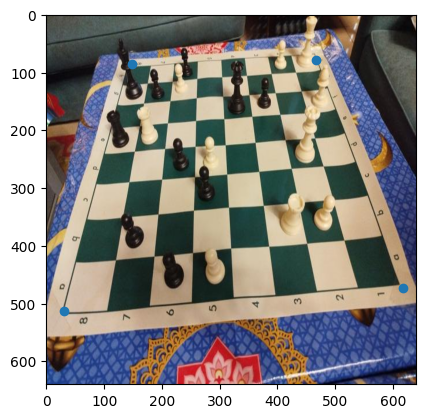

In [30]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(corners_up_2d[:,0], corners_up_2d[:,1]);

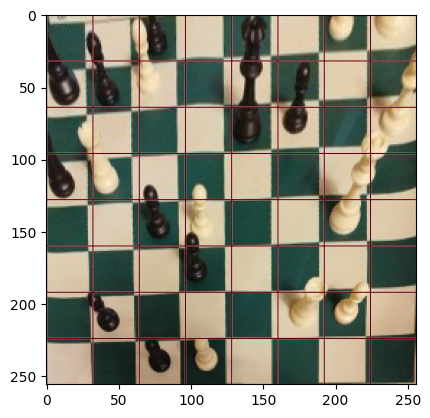

In [37]:
M = cv2.getPerspectiveTransform(img.board_detection.cpu().numpy().astype(np.float32), np.array([
    [0,0],
    [256,0],
    [256,256],
    [0,256],
], dtype=np.float32))
M = torch.tensor(M)

warpped_img = cv2.warpPerspective(img.img.permute(1,2,0).numpy(), M.numpy(), (256,256))
plt.imshow(warpped_img);

grid = np.zeros((256,256))
grid[::32, :] = 1
grid[:, ::32] = 1
plt.imshow(grid, alpha = grid, cmap="Reds");

In [38]:
r = 2
c = 2

In [39]:
sq_box = np.array([
    [(c-1)*32, (r-1)*32],
    [(c)*32, (r-1)*32],
    [(c)*32, (r)*32],
    [(c-1)*32, (r)*32],
], dtype=np.float32)

In [40]:
M_inv = np.linalg.inv(M)

inverted_sq = []

for i in range(len(sq_box)):
    inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))
    inverted_sq[-1] = (inverted_sq[-1] / inverted_sq[-1][2])[:2]

inverted_sq = np.stack(inverted_sq, axis=0)
inverted_sq

/tmp/ipykernel_336828/1142479384.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))


array([[     183.35,      114.17],
       [     226.64,      113.07],
       [     222.95,      146.84],
       [     176.79,      148.18]])

In [41]:
pts = trace_ray(from_2d_to_3d(inverted_sq, K, R), cam_point, np.zeros(4)) + np.concat([np.zeros((4,2)), .1*np.ones((4,1))], axis=1)
pts2 = from_3d_to_2d(pts, K, R)

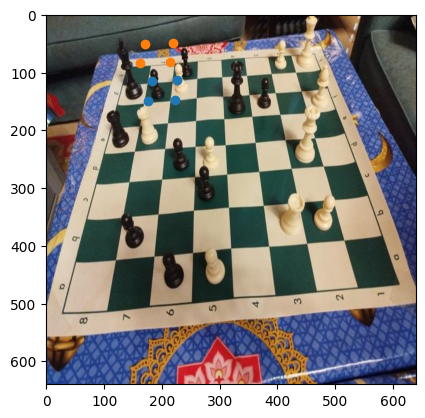

In [42]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(inverted_sq[:,0], inverted_sq[:,1]);
plt.scatter(pts2[:,0], pts2[:,1]);

In [43]:
xs = np.linspace(0,256, 9)
ys = np.linspace(0,256, 9)

X, Y = np.meshgrid(xs, ys)
points = np.stack([X,Y], axis=2)

points.shape, X.shape, Y.shape, points[3,6]

((9, 9, 2), (9, 9), (9, 9), array([        192,          96]))

In [44]:
tmp = np.concat([points, np.ones((9,9,1))], axis=2) @ M_inv.numpy().T

tmp = (tmp/tmp[:, :, [2]])[:, :, :2].reshape(-1, 2)
tmp

array([[        148,          85],
       [     189.14,      84.097],
       [     229.91,      83.203],
       [     270.31,      82.316],
       [     310.36,      81.437],
       [     350.04,      80.567],
       [     389.37,      79.703],
       [     428.36,      78.848],
       [        467,          78],
       [     139.63,      115.27],
       [     183.35,      114.17],
       [     226.64,      113.07],
       [     269.52,      111.99],
       [        312,      110.92],
       [     354.07,      109.86],
       [     395.75,       108.8],
       [     437.03,      107.76],
       [     477.94,      106.73],
       [     130.17,      149.53],
       [     176.79,      148.18],
       [     222.95,      146.84],
       [     268.63,      145.52],
       [     313.85,      144.21],
       [     358.62,      142.91],
       [     402.94,      141.62],
       [     446.81,      140.35],
       [     490.26,      139.09],
       [     119.36,      188.63],
       [     169.32,

In [45]:
elevated_tmp = trace_ray(from_2d_to_3d(tmp, K, R), cam_point, np.zeros((81)))
elevated_tmp += np.concat([np.zeros((81,2)), .1*np.ones((81, 1))], axis=1)
elevated_tmp = from_3d_to_2d(elevated_tmp, K, R)
elevated_tmp

array([[     133.18,      21.553],
       [      178.1,      20.883],
       [     222.59,      20.219],
       [     266.64,      19.562],
       [     310.25,      18.911],
       [     353.45,      18.266],
       [     396.23,      17.628],
       [      438.6,      16.996],
       [     480.56,       16.37],
       [        123,      50.453],
       [     171.01,      49.585],
       [     218.51,      48.725],
       [     265.52,      47.875],
       [     312.05,      47.034],
       [     358.09,      46.201],
       [     403.65,      45.377],
       [     448.75,      44.562],
       [     493.39,      43.755],
       [     111.33,      83.557],
       [     162.88,      82.439],
       [     213.85,      81.333],
       [     264.25,       80.24],
       [     314.09,      79.158],
       [     363.38,      78.089],
       [     412.12,      77.031],
       [     460.33,      75.985],
       [     508.01,      74.951],
       [     97.842,      121.86],
       [     153.49,

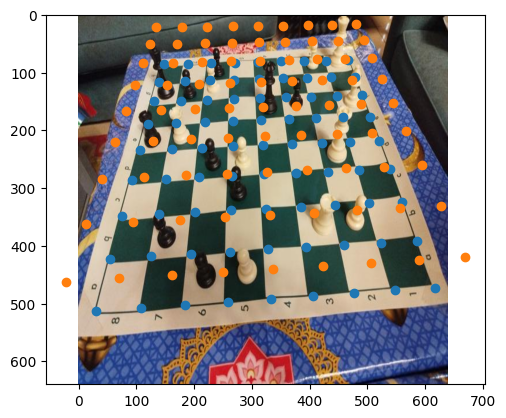

In [46]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(tmp[:,0], tmp[:,1]);
plt.scatter(elevated_tmp[:,0], elevated_tmp[:,1]);